## 5. Enhancing K-means Clustering with Association Rule Mining (35 points).

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data & Apply Feature Engineering
df = pd.read_csv("mobile_price.csv")

# Combine related spatial dimensions to prevent "double voting" in Euclidean distance
df['total_pixels'] = df['px_height'] * df['px_width']
df['screen_area'] = df['sc_h'] * df['sc_w']

# Drop the target and the redundant original features
X = df.drop(['price_range', 'px_height', 'px_width', 'sc_h', 'sc_w'], axis=1)
y = df['price_range']

# 2. Standardize Original Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Helper function to map unsupervised clusters to true labels via Majority Voting
def map_clusters_to_labels(true_labels, cluster_labels):
    mapped_labels = np.zeros_like(cluster_labels)
    for i in np.unique(cluster_labels):
        mask = (cluster_labels == i)
        if np.sum(mask) > 0:
            # Handle ties and return a scalar
            majority_label = pd.Series(true_labels[mask]).mode()[0]
            mapped_labels[mask] = majority_label
    return mapped_labels

# Helper function to evaluate K-means over multiple seeds
def evaluate_kmeans(X_data, y_true, seeds):
    metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    for seed in seeds:
        kmeans = KMeans(n_clusters=4, random_state=seed, n_init=10)
        clusters = kmeans.fit_predict(X_data)
        mapped_preds = map_clusters_to_labels(y_true, clusters)
        
        metrics['acc'].append(accuracy_score(y_true, mapped_preds))
        metrics['prec'].append(precision_score(y_true, mapped_preds, average='weighted', zero_division=0))
        metrics['rec'].append(recall_score(y_true, mapped_preds, average='weighted', zero_division=0))
        metrics['f1'].append(f1_score(y_true, mapped_preds, average='weighted', zero_division=0))
        
    return {k: np.mean(v) for k, v in metrics.items()}

seeds = [0, 10, 42, 100, 999]

# --- Evaluate Original K-Means ---
orig_metrics = evaluate_kmeans(X_scaled, y, seeds)
print("=== Original K-Means Performance (Average over seeds) ===")
print(f"Accuracy : {orig_metrics['acc']:.4f}")
print(f"Precision: {orig_metrics['prec']:.4f}")
print(f"Recall   : {orig_metrics['rec']:.4f}")
print(f"F1-Score : {orig_metrics['f1']:.4f}\n")

# --- Proposed Improved Method: CAR-Weighted K-Means ---

# Step A: Discretize features into low, medium, high for ARM
X_binned = pd.DataFrame()
for col in X.columns:
    # Treat binary/low-variance columns properly and safely qcut continuous ones
    if X[col].nunique() <= 3:
        X_binned[col] = X[col].astype(str).apply(lambda x: f"{col}_{x}")
    else:
        _, edges = pd.qcut(X[col], q=3, retbins=True, duplicates='drop')
        possible_labels = [f"{col}_low", f"{col}_med", f"{col}_high"]
        actual_labels = possible_labels[:len(edges) - 1]
        X_binned[col] = pd.qcut(X[col], q=3, labels=actual_labels, duplicates='drop')

# Step B: Append target variable to mine Class Association Rules (CARs)
X_binned['target_price'] = y.apply(lambda val: f"price_{val}")

# Step C: Convert to transaction format and run FP-Growth
transactions = X_binned.values.tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

freq_items = fpgrowth(df_trans, min_support=0.05, use_colnames=True)

# Step D: Generate Association Rules with STRICTER thresholds to filter out noise
rules = association_rules(freq_items, metric="lift", min_threshold=1.2)
rules = rules[rules['confidence'] >= 0.4] 

# Step E: Calculate Feature Weights based on Rule Lift
target_labels = {"price_0", "price_1", "price_2", "price_3"}
feature_weights = {col: 0.0 for col in X.columns}

for idx, row in rules.iterrows():
    consequents = list(row['consequents'])
    antecedents = list(row['antecedents'])
    
    # Check if consequent is exactly one of the target price classes
    if len(consequents) == 1 and consequents[0] in target_labels:
        for item in antecedents:
            for col in X.columns:
                if item.startswith(col):
                    feature_weights[col] += row['lift']

# Step F: Normalize weights NON-LINEARLY to a wider range [0.01, 5.0]
weights_array = np.array([feature_weights[col] for col in X.columns])
if weights_array.max() > 0:
    # Scale to 0-1
    weights_array = (weights_array - weights_array.min()) / (weights_array.max() - weights_array.min())
    # Exponentiate to punish weak features and highly reward strong ones
    weights_array = np.power(weights_array, 3) 
    # Scale to 0.01 -> 5.0 range
    weights_array = weights_array * 4.99 + 0.01
else:
    weights_array = np.ones_like(weights_array)

# Step G: Apply the ARM-derived weights to the original standardized features
X_weighted = X_scaled * weights_array

# --- Evaluate Improved ARM-K-Means ---
improved_metrics = evaluate_kmeans(X_weighted, y, seeds)
print("=== Improved CAR-Weighted K-Means Performance ===")
print(f"Accuracy : {improved_metrics['acc']:.4f}")
print(f"Precision: {improved_metrics['prec']:.4f}")
print(f"Recall   : {improved_metrics['rec']:.4f}")
print(f"F1-Score : {improved_metrics['f1']:.4f}")

=== Original K-Means Performance (Average over seeds) ===
Accuracy : 0.2727
Precision: 0.2056
Recall   : 0.2727
F1-Score : 0.2267

=== Improved CAR-Weighted K-Means Performance ===
Accuracy : 0.7515
Precision: 0.7550
Recall   : 0.7515
F1-Score : 0.7524


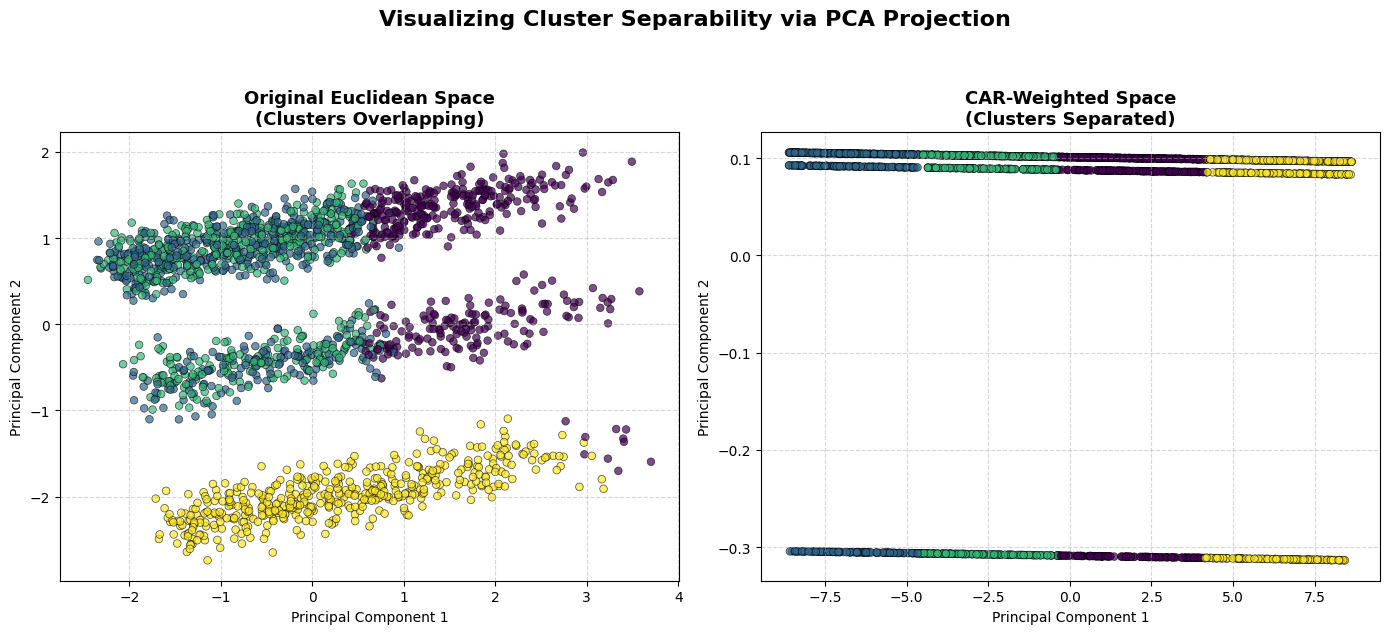

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Dimensionality Reduction Visualization Addendum ---

# 1. Fit PCA to compress the 20+ dimensional spaces down to 2D for plotting
pca_orig = PCA(n_components=2)
X_pca_orig = pca_orig.fit_transform(X_scaled)

pca_weighted = PCA(n_components=2)
X_pca_weighted = pca_pca_weighted = pca_weighted.fit_transform(X_weighted)

# 2. Run K-Means one more time (using seed 42) to get the final labels
kmeans_orig = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_orig = kmeans_orig.fit_predict(X_scaled)

kmeans_weighted = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_weighted = kmeans_weighted.fit_predict(X_weighted)

# 3. Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original Space (Will likely look messy/overlapping)
axes[0].scatter(X_pca_orig[:, 0], X_pca_orig[:, 1], c=clusters_orig, cmap='viridis', alpha=0.7, s=30, edgecolor='k', linewidth=0.5)
axes[0].set_title('Original Euclidean Space\n(Clusters Overlapping)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: CAR-Weighted Space (Should show clear separation)
axes[1].scatter(X_pca_weighted[:, 0], X_pca_weighted[:, 1], c=clusters_weighted, cmap='viridis', alpha=0.7, s=30, edgecolor='k', linewidth=0.5)
axes[1].set_title('CAR-Weighted Space\n(Clusters Separated)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Visualizing Cluster Separability via PCA Projection', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()